In [43]:
import sys
sys.modules.pop("src.classify", None)
sys.modules.pop("src.features", None)
sys.modules.pop("src.utils", None)
from src.classify import load_reference_features, parse_reference_label, classify_card
from src.features import (
    contour_shape_features,
    contour_structural_features,
    contour_to_fourier_descriptor,
    compute_descriptor_from_contours
)
from src.utils import get_card_colour, apply_colour_threshold, find_contours_in_image, process_card_image
from src.config import load_config, set_global_config, get_config_value
import numpy as np
import cv2
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle
import os

config = load_config("config.json")
set_global_config(config)

# Card Classification Pipeline

**Overview:** This notebook demonstrates the end-to-end card classification pipeline, which identifies card value and color from segmented card images using feature-based matching against a reference set.

**Objective:** Extract interpretable features from card images and perform robust classification through reference-based voting, enabling accurate card identification without requiring large training datasets.

**Methodology:** The pipeline combines multiple feature types (shape, structural, and Fourier descriptors) to create a comprehensive card representation, then matches against reference cards using Euclidean distance and voting to achieve robust classification even with limited reference samples.

## Stage 1: Load Reference Card & Detect Color

**Purpose**: Load a sample reference card image and detect its dominant color (Yellow, Red, Green, Blue, or Black).

**Approach**:
- Load reference card features from pre-computed .npz file
- Extract a sample reference card image
- Use HSV-based thresholding to detect dominant card color
- Display the card with color detection visualization

**Output**: Card image with detected color label and thresholded visualization

In [44]:
# Load reference features to understand what cards are available
reference_features_path = get_config_value("paths.reference_features")
labels, features, meta = load_reference_features(reference_features_path)

print(f"Loaded {len(labels)} reference cards")
print(f"Feature dimension: {features.shape[1]}")
print(f"First 10 reference labels: {labels[:10]}")

# Select a reference card to demonstrate (pick a non-augmented variant)
DEMO_LABEL = "b_0"

Loaded 378 reference cards
Feature dimension: 95
First 10 reference labels: ['b_0', 'b_0_a', 'b_0_b', 'b_0_c', 'b_0_d', 'b_0_e', 'b_0_f', 'b_1', 'b_1_a', 'b_1_b']


In [45]:
# For demonstration, we'll create a synthetic reference card image
# by loading from the reference data directory
reference_dir = get_config_value("paths.reference_output_dir", None)

# If reference directory exists, try to load the actual reference card
if reference_dir and os.path.exists(reference_dir):
    # Construct potential image paths
    name = f"cropped/{DEMO_LABEL}.jpg"
    card_img = None

    path = os.path.join(reference_dir, name)
    if os.path.exists(path):
        card_img = cv2.imread(path)
        if card_img is not None:
            card_img_rgb = cv2.cvtColor(card_img, cv2.COLOR_BGR2RGB)
            print(f"Loaded reference card from: {path}")
    
else:
    print("Reference directory not configured or not found")

Loaded reference card from: data/reference_images/cropped/b_0.jpg


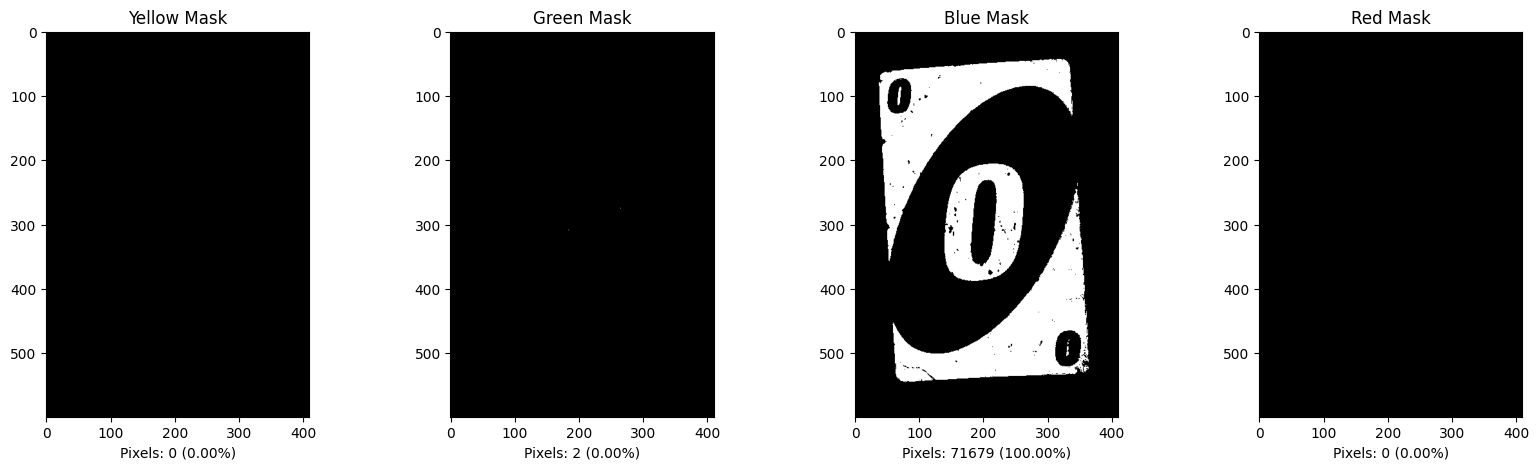

Detected card color: Blue (b)


In [46]:
# Detect the dominant card color
if card_img is not None:
    card_colour = get_card_colour(card_img_rgb, plot=True)
    color_names = {"y": "Yellow", "r": "Red", "g": "Green", "b": "Blue", "k": "Black"}
    color_label = color_names.get(card_colour, "Unknown")
    
    print(f"Detected card color: {color_label} ({card_colour})")
    

## Stage 2: Feature Extraction - Unified Pipeline

**Purpose**: Extract the complete feature set (shape, structural, and Fourier descriptors) from card contours.

**Approach**:
1. **Shape Features (11 total)**:
   - Aspect ratio, extent, solidity, circularity
   - Hu moments (7 values) - invariant to translation, scale, and rotation
   - Capture geometric properties of card symbols

2. **Structural Features (9 total)**:
   - Contour count, area ratios (top 3), area coefficient of variation
   - Perimeter statistics, centroid spread in x/y directions
   - Encode spatial layout and arrangement of symbols on card

3. **Fourier Descriptors**:
   - FFT-based contour representation with rotation, translation, and scale invariance
   - Captures contour shape signatures for matching

**Output**: Combined feature vector with breakdown of individual components

Found 9 contours in card image


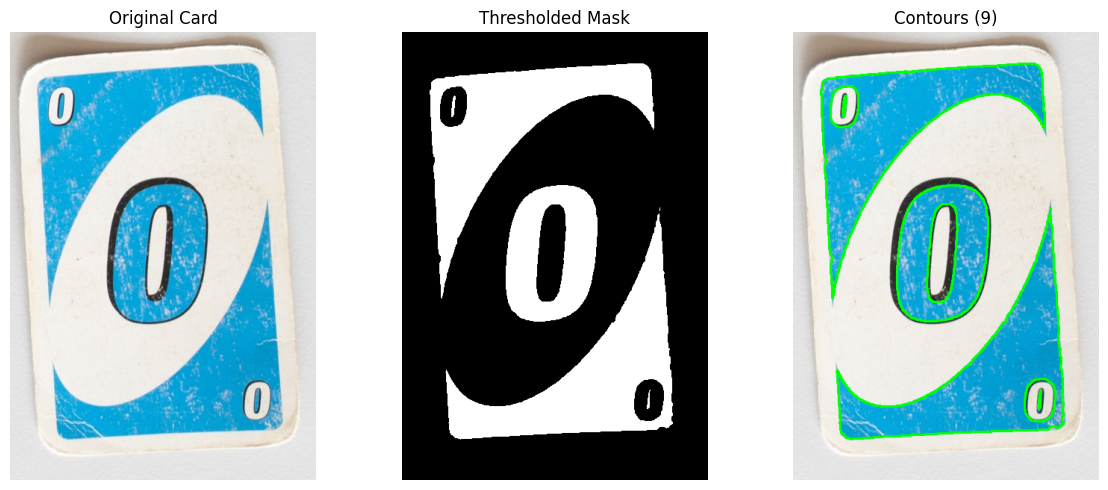

In [47]:
if card_img is not None:
    # Process card image to get contours
    processed = process_card_image(
        card_img_rgb,
        output_root=None,
        save_outputs=False,
        apply_opening_step=False,
        max_contours=15,  # Limit to top 10 contours for demonstration
        verb=True
    )
    
    contours = processed["contours"]
    card_mask = processed["mask"]
    
    print(f"Found {len(contours)} contours in card image")
    
    # Visualize contours
    fig, axes = plt.subplots(1, 3, figsize=(12, 5))
    
    axes[0].imshow(card_img_rgb)
    axes[0].set_title("Original Card")
    axes[0].axis("off")
    
    axes[1].imshow(card_mask, cmap="gray")
    axes[1].set_title("Thresholded Mask")
    axes[1].axis("off")

    contour_viz = card_img_rgb.copy()
    cv2.drawContours(contour_viz, contours, -1, (0, 255, 0), 2)

    axes[2].imshow(contour_viz, cmap="gray")
    axes[2].set_title(f"Contours ({len(contours)})")
    axes[2].axis("off")

    plt.tight_layout()
    plt.show()


Descriptor Component Breakdown:
  Fourier descriptors: 64 values
  Shape features (mean): 11 values
  Shape features (std): 11 values
  Structural features: 9 values
  Total descriptor size: 95

Descriptor Statistics:
  Min: 0.000000
  Max: 9.587276
  Mean: 0.707222
  Std: 1.798183


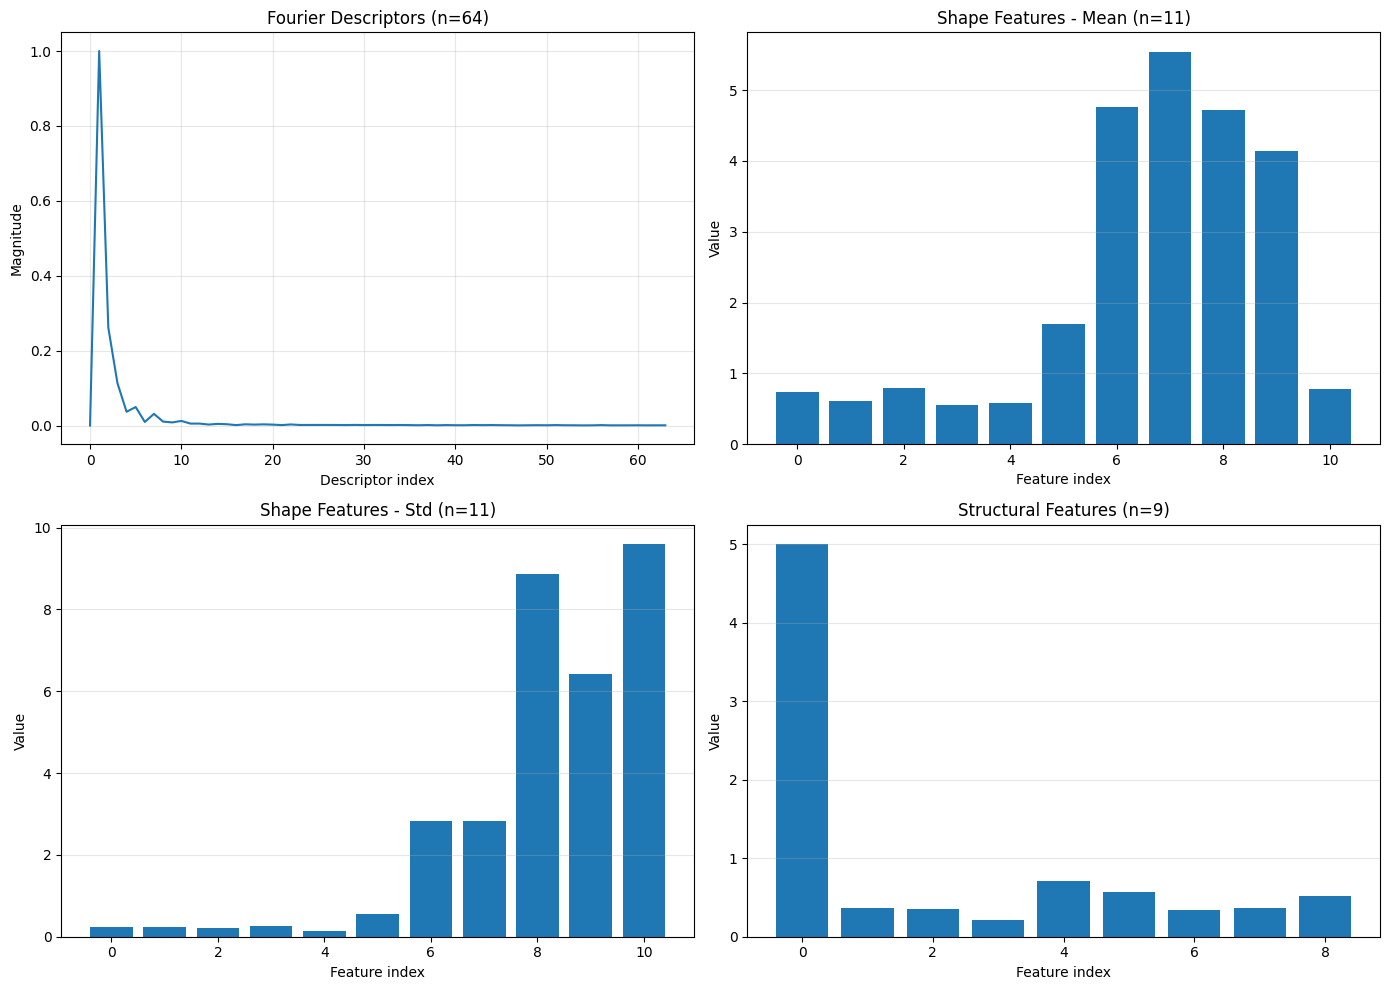

In [72]:
if card_img is not None and len(contours) > 0:
    # Compute complete descriptor
    num_descriptors = get_config_value("feature_extraction.num_descriptors")
    num_points = get_config_value("feature_extraction.num_points")

    max_contours = get_config_value("image_processing.max_contours")
    
    descriptor = compute_descriptor_from_contours(
        contours,
        num_descriptors=num_descriptors,
        num_points=num_points,
        max_contours=max_contours
    )
    
    shape_feature_dim = get_config_value("feature_dimensions.shape_feature_dim")
    struct_feature_dim = get_config_value("feature_dimensions.struct_feature_dim")
    
    # Break down descriptor components
    fourier_size = num_descriptors
    shape_mean_size = shape_feature_dim
    shape_std_size = shape_feature_dim
    struct_size = struct_feature_dim
    
    print(f"\nDescriptor Component Breakdown:")
    print(f"  Fourier descriptors: {fourier_size} values")
    print(f"  Shape features (mean): {shape_mean_size} values")
    print(f"  Shape features (std): {shape_std_size} values")
    print(f"  Structural features: {struct_size} values")
    print(f"  Total descriptor size: {len(descriptor)}")
    
    # Display descriptor statistics
    print(f"\nDescriptor Statistics:")
    print(f"  Min: {np.min(descriptor):.6f}")
    print(f"  Max: {np.max(descriptor):.6f}")
    print(f"  Mean: {np.mean(descriptor):.6f}")
    print(f"  Std: {np.std(descriptor):.6f}")
    
    # Plot descriptor components
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    
    # Fourier descriptors (magnitude)
    fourier_desc = descriptor[:fourier_size]
    axes[0, 0].plot(np.abs(fourier_desc))
    axes[0, 0].set_title(f"Fourier Descriptors (n={fourier_size})")
    axes[0, 0].set_xlabel("Descriptor index")
    axes[0, 0].set_ylabel("Magnitude")
    axes[0, 0].grid(True, alpha=0.3)
    
    # Shape features (mean)
    shape_mean = descriptor[fourier_size:fourier_size+shape_mean_size]
    axes[0, 1].bar(range(len(shape_mean)), shape_mean)
    axes[0, 1].set_title(f"Shape Features - Mean (n={shape_mean_size})")
    axes[0, 1].set_xlabel("Feature index")
    axes[0, 1].set_ylabel("Value")
    axes[0, 1].grid(True, alpha=0.3, axis="y")
    
    # Shape features (std)
    shape_std = descriptor[fourier_size+shape_mean_size:fourier_size+2*shape_mean_size]
    axes[1, 0].bar(range(len(shape_std)), shape_std)
    axes[1, 0].set_title(f"Shape Features - Std (n={shape_std_size})")
    axes[1, 0].set_xlabel("Feature index")
    axes[1, 0].set_ylabel("Value")
    axes[1, 0].grid(True, alpha=0.3, axis="y")
    
    # Structural features
    struct = descriptor[fourier_size+2*shape_mean_size:]
    axes[1, 1].bar(range(len(struct)), struct)
    axes[1, 1].set_title(f"Structural Features (n={struct_size})")
    axes[1, 1].set_xlabel("Feature index")
    axes[1, 1].set_ylabel("Value")
    axes[1, 1].grid(True, alpha=0.3, axis="y")
    
    plt.tight_layout()
    plt.show()

Feature Type Explanations:

1. FOURIER DESCRIPTORS (Rotation, Scale, Translation Invariant):
- FFT-based representation of contour shape
- Captures essential contour signature for matching
- Invariances enable robust matching across different card orientations and sizes

2. SHAPE FEATURES (Geometric Properties):
- Aspect ratio: width/height of bounding box
- Extent: contour area / bounding box area
- Solidity: contour area / convex hull area
- Circularity: 4π·area / perimeter²
- Hu moments: 7 scale/rotation invariant moment descriptors: 

3. STRUCTURAL FEATURES (Spatial Layout):
- Number of contours detected
- Area ratios: relative sizes of largest/2nd/3rd contours
- Area variation: coefficient of variation across contours
- Perimeter statistics: normalized by largest perimeter
- Centroid spread: distribution of symbol centers in x/y directions
- Coverage: total area / image bounding box

## Stage 3: Classification via Reference Matching & Voting

**Purpose**: Match the test card descriptor against reference cards using nearest-neighbour search and an optional voting fallback to determine card value and colour.

**Approach**:
1. **Distance Computation**: Euclidean distance is computed from the (optionally normalised) test descriptor to all candidate reference descriptors. Candidates are pre-filtered by card colour: black cards are matched only against `wild`/`draw_4` references; all others exclude those classes.
2. **Variant Deduplication**: Where multiple reference variants exist for a base label (e.g. `_top`, `_bottom`, `_a`, `_b`), only the closest variant is retained, yielding one distance per unique base label.
3. **Confidence Estimation**: Confidence is derived from the ratio of the best to second-best distance — $\text{conf}
4. **Voting Fallback**: If $\text{conf} < \texttt{vote\_min\_conf}$, a vote is taken over the top-$k$ base labels. Each label contributes one vote for its **value** component. The winning value must reach $\texttt{vote\_min\_count}$ votes; ties are broken by earliest appearance in the top-$k$ ranking.
5. **Label Construction**: The predicted label is assembled from the **detected** card colour and the matched (or voted) value, except for `wild`/`draw_4` which are colour-independent.

**Output**: Top-$k$ matched references with distances, distance ratio, confidence score, decision path (`top1` or `vote`), and final predicted label.

In [62]:
if card_img is not None and len(contours) > 0:
    # Compute distances to all reference features
    distances = np.sqrt(np.sum((features - descriptor) ** 2, axis=1))
    
    # Get top-k matches
    top_k = get_config_value("matching.top_k")
    top_k_indices = np.argsort(distances)[:top_k]
    top_k_distances = distances[top_k_indices]
    
    labels = np.array(labels)
    top_k_labels = labels[top_k_indices]
    
    print(f"\nTop {top_k} Nearest Reference Cards:")
    print(f"{'Rank':<6} {'Label':<20} {'Distance':<12} {'Similarity':<12}")
    print("-" * 50)
    
    # Normalize distances to confidence scores (inverse distance)
    min_dist = np.min(top_k_distances)
    max_dist = np.max(top_k_distances)
    
    confidences = []
    for rank, (idx, dist, label) in enumerate(zip(top_k_indices, top_k_distances, top_k_labels), 1):
        # Normalize distance to 0-1 confidence (0=worst, 1=best)
        if max_dist > min_dist:
            confidence = 1.0 - (dist - min_dist) / (max_dist - min_dist)
        else:
            confidence = 1.0
        confidences.append(confidence)
        
        parsed = parse_reference_label(label)
        print(f"{rank:<6} {label:<20} {dist:<12.4f} {confidence:<12.4f}")
    
    confidences = np.array(confidences)


Top 5 Nearest Reference Cards:
Rank   Label                Distance     Similarity  
--------------------------------------------------
1      b_0                  0.0000       1.0000      
2      b_8                  2.9105       0.3493      
3      g_9_f                4.1475       0.0728      
4      r_8_a                4.3580       0.0257      
5      r_0_b                4.4731       0.0000      


In [69]:
# Implement voting mechanism
vote_min_conf = float(get_config_value("matching.vote_min_conf"))
vote_min_count = int(get_config_value("matching.vote_min_count"))

print(f"\nVoting Configuration:")
print(f"  vote_min_conf (confidence threshold): {vote_min_conf}")
print(f"  vote_min_count (minimum votes required): {vote_min_count}")

# Recompute confidence from distance ratio (mirrors function logic)
best_distance  = top_k_distances[0]
second_distance = top_k_distances[1] if len(top_k_distances) > 1 else best_distance
ratio      = best_distance / (second_distance + 1e-6)
confidence = max(0.0, min(1.0, 1.0 - ratio))

print(f"\n  Best distance:    {best_distance:.4f}")
print(f"  Second distance:  {second_distance:.4f}")
print(f"  Distance ratio:   {ratio:.4f}")
print(f"  Confidence:       {confidence:.4f}")
print(f"  Triggers voting:  {'YES' if confidence < vote_min_conf else 'NO'}")

# top_k_labels and top_k_distances are already base labels (post-dedup, sorted by distance)
top_entries = list(zip(top_k_labels, top_k_distances))

print(f"\nTop-K Entries:")
print(f"{'Rank':<6} {'Label':<20} {'Distance':<12}")
print("-" * 40)
for rank, (label, dist) in enumerate(top_entries, 1):
    print(f"{rank:<6} {label:<20} {dist:<12.4f}")

# Determine decision path
decision     = "top1"
voted_value  = None
matched_label = top_k_labels[0]
card_colour, matched_value = parse_reference_label(matched_label)

predicted = (
    matched_value
    if matched_value in ("wild", "draw_4")
    else f"{card_colour}_{matched_value}"
)

if confidence < vote_min_conf:
    # Count votes per value, preserving first-seen rank
    value_counts: dict = {}
    first_seen:   dict = {}

    for idx, (label, _dist) in enumerate(top_entries):
        _colour, value = parse_reference_label(label)
        value_counts[value] = value_counts.get(value, 0) + 1
        if value not in first_seen:
            first_seen[value] = idx

    print(f"\nVote Counts:")
    print(f"{'Value':<20} {'Count':<10} {'First Seen Rank':<16} {'Passes':<8}")
    print("-" * 56)
    for value, count in sorted(value_counts.items(), key=lambda x: first_seen[x[0]]):
        passes = count >= vote_min_count
        print(f"{value:<20} {count:<10} {first_seen[value]:<16} {'YES' if passes else 'NO'}")

    candidates = [v for v, count in value_counts.items() if count >= vote_min_count]

    if candidates:
        voted_value = min(candidates, key=lambda v: first_seen[v])
        predicted   = (
            voted_value
            if voted_value in ("wild", "draw_4")
            else f"{card_colour}_{voted_value}"
        )
        decision = "vote"

print(f"\nFinal Classification:")
print(f"  Decision:        {decision}")
print(f"  Predicted Label: {predicted}")
print(f"  Matched Label:   {matched_label}")
print(f"  Matched Value:   {matched_value}")
if voted_value:
    print(f"  Voted Value:     {voted_value}")


Voting Configuration:
  vote_min_conf (confidence threshold): 0.12
  vote_min_count (minimum votes required): 2

  Best distance:    0.0000
  Second distance:  2.9105
  Distance ratio:   0.0000
  Confidence:       1.0000
  Triggers voting:  NO

Top-K Entries:
Rank   Label                Distance    
----------------------------------------
1      b_0                  0.0000      
2      b_8                  2.9105      
3      g_9_f                4.1475      
4      r_8_a                4.3580      
5      r_0_b                4.4731      

Final Classification:
  Decision:        top1
  Predicted Label: b_0
  Matched Label:   b_0
  Matched Value:   0


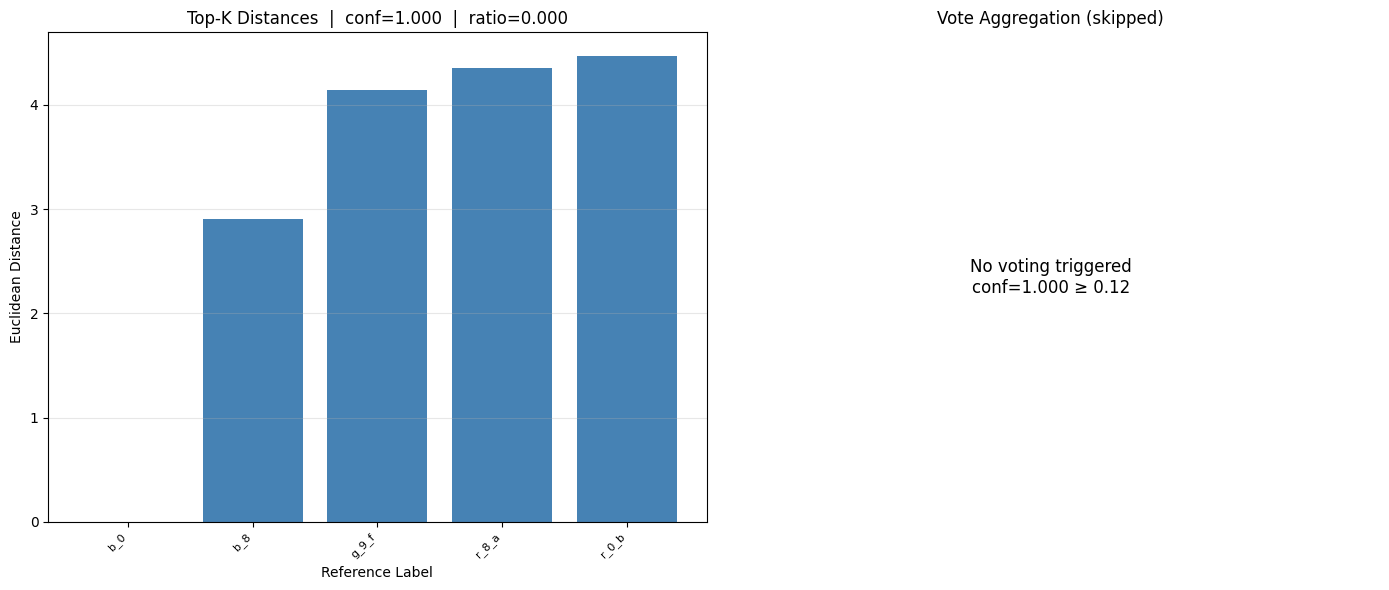


FINAL CLASSIFICATION RESULT
Reference Label:  b_0
Predicted Label:  b_0
Decision:         top1
Confidence:       1.0000  (ratio: 0.0000)
Match:            ✓ CORRECT


In [73]:
if card_img is not None and len(contours) > 0:
    fig, axes = plt.subplots(1, 2, figsize=(14, 6))

    # --- Left: Top-K distances ---
    top_k_base_labels = [label for label, _ in top_entries]
    colors_list = ['steelblue'] * len(top_k_distances)
    colors_list[0] = 'green' if decision == 'top1' else 'orange'
    axes[0].bar(range(1, len(top_k_distances) + 1), top_k_distances, color=colors_list)
    axes[0].set_xticks(range(1, len(top_k_distances) + 1))
    axes[0].set_xticklabels(top_k_base_labels, rotation=45, ha='right', fontsize=8)
    axes[0].set_xlabel('Reference Label')
    axes[0].set_ylabel('Euclidean Distance')
    axes[0].set_title(f'Top-K Distances  |  conf={confidence:.3f}  |  ratio={ratio:.3f}')
    axes[0].grid(True, alpha=0.3, axis='y')

    # --- Right: Vote counts per value ---
    if confidence < vote_min_conf and value_counts:
        values_list  = sorted(value_counts.keys(), key=lambda v: first_seen[v])
        counts_list  = [value_counts[v] for v in values_list]
        colors_agg   = ['green' if c >= vote_min_count else 'salmon' for c in counts_list]
        axes[1].barh(values_list, counts_list, color=colors_agg)
        axes[1].axvline(x=vote_min_count, color='blue', linestyle='--',
                        label=f'vote_min_count={vote_min_count}')
        axes[1].set_xlabel('Vote Count')
        axes[1].set_title(f'Votes by Value  |  winner: {voted_value}  |  decision: vote')
        axes[1].legend()
        axes[1].grid(True, alpha=0.3, axis='x')
    else:
        axes[1].text(0.5, 0.5, f'No voting triggered\nconf={confidence:.3f} ≥ {vote_min_conf}',
                     ha='center', va='center', fontsize=12, transform=axes[1].transAxes)
        axes[1].set_title('Vote Aggregation (skipped)')
        axes[1].axis('off')

    plt.tight_layout()
    plt.show()

    # --- Final result summary ---
    correct = predicted == demo_label
    print(f"\n{'='*50}")
    print(f"FINAL CLASSIFICATION RESULT")
    print(f"{'='*50}")
    print(f"Reference Label:  {demo_label}")
    print(f"Predicted Label:  {predicted}")
    print(f"Decision:         {decision}" + (f"  (voted value: {voted_value})" if voted_value else ""))
    print(f"Confidence:       {confidence:.4f}  (ratio: {ratio:.4f})")
    print(f"Match:            {'✓ CORRECT' if correct else '✗ INCORRECT'}")
    print(f"{'='*50}")

## Design Justifications

### Why Feature-Based Over Deep Learning?
- **Interpretability**: Each feature carries geometric or spatial meaning; decisions can be examined by inspecting which reference cards matched and at what distance
- **No Training Data Required**: Operates directly from a limited reference set without large labelled datasets
- **Robustness**: Hand-crafted features encode domain knowledge about card structure, with invariances constructed explicitly rather than learned implicitly

### Why Three Feature Types?
- **Shape Features**: Capture per-symbol geometry (aspect ratio, solidity, Hu moments), essential for distinguishing visually similar symbols
- **Structural Features**: Encode spatial layout and symbol arrangement across the card region
- **Fourier Descriptors**: Provide contour-level descriptors with built-in rotation, scale, and translation invariance
- **Combined**: No single feature type is sufficient alone; the concatenated descriptor produces a more complete and discriminative card representation

### Why Fourier Invariances?
- **Translation Invariance**: The DC coefficient ($k=0$) is discarded, removing dependence on absolute contour position
- **Rotation Invariance**: Taking $|F(k)|$ removes phase, making the descriptor independent of the contour traversal start point
- **Scale Invariance**: Normalising by $|F(1)|$ removes dependence on overall contour magnitude
- **Impact**: Enables reliable matching across reference and test cards that differ in orientation or spatial scale

### Why Top-K Voting ($K=5$)?
- **Conditional Trigger**: Voting is only invoked when the distance-ratio confidence falls below `vote_min_conf`; high-confidence matches use the nearest neighbour directly (`top1`)
- **Robustness**: When voting is triggered, requiring `vote_min_count` agreeing values prevents a single outlier variant from determining the prediction
- **Variant Deduplication**: Each base label contributes at most one vote (the closest variant), so $K=5$ represents five distinct card identities rather than five raw descriptor matches
- **Winner Selection**: The winning value is the earliest-appearing candidate that reaches the count threshold, prioritising proximity over frequency

### Why This Confidence Formulation?
- **Distance Ratio**: Confidence captures the relative separation between the best and second-best match, not absolute distance magnitude; a low ratio indicates an unambiguous n